<a href="https://colab.research.google.com/github/irumvaa/Projects/blob/main/Justify_project_Designing_the_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [7]:
import pandas as pd
import zipfile
import os

In [8]:
# Extract and load loan_prediction_dataset.csv
zip_file_path_loan = '/content/archive.zip'
csv_file_name_loan = 'loan_prediction_dataset.csv'

with zipfile.ZipFile(zip_file_path_loan, 'r') as zip_ref:
    zip_ref.extract(csv_file_name_loan, '/content/')

df_loan = pd.read_csv(os.path.join('/content/', csv_file_name_loan))
print("Head of loan_prediction_dataset.csv:")
print(df_loan.head())
print("\n")

Head of loan_prediction_dataset.csv:
   age     income  credit_score  dependents  home_owner  loan_approved
0   54  100000.00           334           0           1              1
1   67   85233.42           593           2           1              1
2   29   16737.15           502           0           0              1
3   42   69332.50           367           3           0              0
4   58   28211.14           430           0           1              1




In [9]:
# Extract and load household-debt-by-state.csv
zip_file_path_debt = '/content/household-debt-by-state DTI.zip'
csv_file_name_debt = 'household-debt-by-state.csv'

with zipfile.ZipFile(zip_file_path_debt, 'r') as zip_ref:
    zip_ref.extract(csv_file_name_debt, '/content/')

df_debt = pd.read_csv(os.path.join('/content/', csv_file_name_debt))
print("Head of household-debt-by-state.csv:")
print(df_debt.head())

Head of household-debt-by-state.csv:
   year  qtr  state_fips   low  high
0  1999    1           1  0.40  1.11
1  1999    1           2  1.24  1.32
2  1999    1           4  1.32  1.40
3  1999    1           5  0.40  1.11
4  1999    1           6  1.60  1.72


In [10]:
print("df_loan Info:")
df_loan.info()
print("\n")
print("df_loan Description:")
df_loan.describe()
print("\n")

print("df_debt Info:")
df_debt.info()
print("\n")
print("df_debt Description:")
df_debt.describe()

df_loan Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1000 non-null   int64  
 1   income         1000 non-null   float64
 2   credit_score   1000 non-null   int64  
 3   dependents     1000 non-null   int64  
 4   home_owner     1000 non-null   int64  
 5   loan_approved  1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


df_loan Description:


df_debt Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5353 entries, 0 to 5352
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        5353 non-null   int64  
 1   qtr         5353 non-null   int64  
 2   state_fips  5353 non-null   int64  
 3   low         5353 non-null   float64
 4   high        4940 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 209

,year,qtr,state_fips,low,high
count,5353.000000,5353.000000,5353.000000,5353.000000,4940.000000
mean,2011.623949,2.485335,28.968242,1.367499,1.495992
std,7.576836,1.122296,15.676479,0.431216,0.279479
min,1999.000000,1.000000,1.000000,0.400000,1.110000
25%,2005.000000,1.000000,16.000000,1.110000,1.240000
50%,2012.000000,2.000000,29.000000,1.400000,1.500000
75%,2018.000000,3.000000,42.000000,1.600000,1.720000
max,2025.000000,4.000000,56.000000,2.060000,2.060000


### Data Preprocessing: Handling Missing Values

First, let's check for missing values in both DataFrames.

In [12]:
print("Missing values in df_loan:")
print(df_loan.isnull().sum())
print("\nMissing values in df_debt:")
print(df_debt.isnull().sum())

Missing values in df_loan:
age              0
income           0
credit_score     0
dependents       0
home_owner       0
loan_approved    0
dtype: int64

Missing values in df_debt:
year            0
qtr             0
state_fips      0
low             0
high          413
dtype: int64


As observed, `df_debt` has missing values in the `high` column. I will impute these missing values using the mean of the `high` column.

In [18]:
# Impute missing 'high' values in df_debt with the mean
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
df_debt['high'] = df_debt['high'].fillna(df_debt['high'].mean())

print("Missing values in df_debt after imputation:")
print(df_debt.isnull().sum())

Missing values in df_debt after imputation:
year          0
qtr           0
state_fips    0
low           0
high          0
dtype: int64


### Preparing `df_loan` for Modeling

Now, let's prepare the `df_loan` dataset. Our goal is to predict `loan_approved`. We need to separate the features (X) from the target variable (y) and then split the data into training and testing sets. We will also scale the numerical features to ensure that features with larger values do not disproportionately influence the model.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y) for df_loan
X = df_loan.drop('loan_approved', axis=1)
y = df_loan['loan_approved']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 5)
X_test shape: (200, 5)
y_train shape: (800,)
y_test shape: (200,)


In [15]:
# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns to scale
numerical_cols = ['age', 'income', 'credit_score', 'dependents'] # 'home_owner' is binary, no need to scale

# Apply scaling to numerical features
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaled X_train head:")
print(X_train.head())
print("\nScaled X_test head:")
print(X_test.head())

Scaled X_train head:
          age    income  credit_score  dependents  home_owner
14   1.140294  0.174997     -1.405022   -0.006124           0
795 -1.738781  0.383981     -1.582792   -0.006124           1
199  0.492502  0.207417      1.445419   -1.406002           0
34   0.420525 -0.865200      1.230870   -0.006124           1
552 -0.299244  0.203810     -0.393575   -1.406002           1

Scaled X_test head:
          age    income  credit_score  dependents  home_owner
272 -0.731105 -0.840298     -1.116913    1.393753           0
912  0.060641 -0.030637      0.109083    1.393753           1
314 -0.659128 -0.681653      0.593351   -0.006124           0
190  0.204594  2.416762      1.316689    1.393753           0
786 -0.227267 -0.805326     -0.375185   -0.706063           0


### Model Selection and Training (Logistic Regression)

For a binary classification task like `loan_approved`, Logistic Regression is a good starting point. It's simple, interpretable, and performs well for many classification problems.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

Let's evaluate the performance of our trained model on the test set.

In [17]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Accuracy: 0.8600

Confusion Matrix:
 [[ 28  16]
 [ 12 144]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.64      0.67        44
           1       0.90      0.92      0.91       156

    accuracy                           0.86       200
   macro avg       0.80      0.78      0.79       200
weighted avg       0.86      0.86      0.86       200



### Model Enhancement: Trying a RandomForestClassifier

Let's try a more robust model like RandomForestClassifier, which is an ensemble learning method and often performs better on various datasets. We will then compare its performance to the Logistic Regression model.

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


### Evaluate RandomForestClassifier Performance

Now, let's evaluate the performance of our Random Forest model on the test set.

In [20]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"RandomForestClassifier Accuracy: {accuracy_rf:.4f}")
print("\nRandomForestClassifier Confusion Matrix:\n", conf_matrix_rf)
print("\nRandomForestClassifier Classification Report:\n", class_report_rf)

RandomForestClassifier Accuracy: 0.8450

RandomForestClassifier Confusion Matrix:
 [[ 26  18]
 [ 13 143]]

RandomForestClassifier Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.59      0.63        44
           1       0.89      0.92      0.90       156

    accuracy                           0.84       200
   macro avg       0.78      0.75      0.76       200
weighted avg       0.84      0.84      0.84       200



### Testing the Logistic Regression Model with Custom Values

Let's test the Logistic Regression model with 10 custom input values to see its predictions. I'll create a DataFrame for these values, scale them using the `StandardScaler` that was fitted on the training data, and then use the `model` to predict `loan_approved`.

In [21]:
# Define 10 custom test cases
custom_test_data = [
    {'age': 30, 'income': 60000, 'credit_score': 700, 'dependents': 1, 'home_owner': 1},
    {'age': 55, 'income': 120000, 'credit_score': 800, 'dependents': 0, 'home_owner': 1},
    {'age': 22, 'income': 35000, 'credit_score': 550, 'dependents': 2, 'home_owner': 0},
    {'age': 40, 'income': 80000, 'credit_score': 680, 'dependents': 3, 'home_owner': 1},
    {'age': 60, 'income': 45000, 'credit_score': 600, 'dependents': 0, 'home_owner': 0},
    {'age': 28, 'income': 70000, 'credit_score': 720, 'dependents': 0, 'home_owner': 0},
    {'age': 45, 'income': 95000, 'credit_score': 750, 'dependents': 2, 'home_owner': 1},
    {'age': 35, 'income': 50000, 'credit_score': 620, 'dependents': 1, 'home_owner': 0},
    {'age': 50, 'income': 110000, 'credit_score': 780, 'dependents': 1, 'home_owner': 1},
    {'age': 25, 'income': 40000, 'credit_score': 580, 'dependents': 0, 'home_owner': 0}
]

df_custom_test = pd.DataFrame(custom_test_data)

print("Custom Test Data:")
display(df_custom_test)

Custom Test Data:


,age,income,credit_score,dependents,home_owner
0,30,60000,700,1,1
1,55,120000,800,0,1
2,22,35000,550,2,0
3,40,80000,680,3,1
4,60,45000,600,0,0
5,28,70000,720,0,0
6,45,95000,750,2,1
7,35,50000,620,1,0
8,50,110000,780,1,1
9,25,40000,580,0,0


In [22]:
# Scale the numerical features of the custom test data
df_custom_test_scaled = df_custom_test.copy()
df_custom_test_scaled[numerical_cols] = scaler.transform(df_custom_test[numerical_cols])

print("Scaled Custom Test Data (head):")
display(df_custom_test_scaled.head())

Scaled Custom Test Data (head):


,age,income,credit_score,dependents,home_owner
0,-1.019013,0.998653,0.758861,-0.706063,1
1,0.780409,3.125817,1.371859,-1.406002,1
2,-1.594828,0.112334,-0.160636,-0.006124,0
3,-0.299244,1.707707,0.636261,0.693814,1
4,1.140294,0.466861,0.145863,-1.406002,0


In [23]:
# Make predictions using the Logistic Regression model
custom_predictions = model.predict(df_custom_test_scaled)

# Add predictions to the original custom test DataFrame for easy viewing
df_custom_test['predicted_loan_approved'] = custom_predictions

print("Predictions for Custom Test Cases:")
display(df_custom_test)

Predictions for Custom Test Cases:


,age,income,credit_score,dependents,home_owner,predicted_loan_approved
0,30,60000,700,1,1,1
1,55,120000,800,0,1,1
2,22,35000,550,2,0,1
3,40,80000,680,3,1,1
4,60,45000,600,0,0,1
5,28,70000,720,0,0,1
6,45,95000,750,2,1,1
7,35,50000,620,1,0,1
8,50,110000,780,1,1,1
9,25,40000,580,0,0,1


### Generating and Testing with 200 Custom Values

To further test the model, I will generate 200 new custom test cases. These will be created by sampling within the observed ranges of the original `df_loan` dataset to ensure they are realistic. After generating, scaling, and predicting, I will display the first few rows of these new test cases with their predictions.

In [24]:
import numpy as np

# Define ranges for each feature based on df_loan (or reasonable assumptions)
min_age, max_age = df_loan['age'].min(), df_loan['age'].max()
min_income, max_income = df_loan['income'].min(), df_loan['income'].max()
min_credit_score, max_credit_score = df_loan['credit_score'].min(), df_loan['credit_score'].max()
min_dependents, max_dependents = df_loan['dependents'].min(), df_loan['dependents'].max()

# Generate 200 random custom test cases
np.random.seed(42) # for reproducibility
extended_custom_test_data = []
for _ in range(200):
    age = np.random.randint(min_age, max_age + 1)
    income = np.random.uniform(min_income, max_income)
    credit_score = np.random.randint(min_credit_score, max_credit_score + 1)
    dependents = np.random.randint(min_dependents, max_dependents + 1)
    home_owner = np.random.randint(0, 2) # 0 or 1
    extended_custom_test_data.append({
        'age': age,
        'income': income,
        'credit_score': credit_score,
        'dependents': dependents,
        'home_owner': home_owner
    })

df_custom_test_extended = pd.DataFrame(extended_custom_test_data)

print("Extended Custom Test Data (first 5 rows):")
display(df_custom_test_extended.head())

Extended Custom Test Data (first 5 rows):


,age,income,credit_score,dependents,home_owner
0,58,80468.126739,570,2,1
1,40,18977.789482,766,2,0
2,43,36036.026669,430,4,1
3,43,83914.493517,685,3,0
4,52,33207.255324,321,4,1


In [25]:
# Scale the numerical features of the extended custom test data
df_custom_test_extended_scaled = df_custom_test_extended.copy()
df_custom_test_extended_scaled[numerical_cols] = scaler.transform(df_custom_test_extended[numerical_cols])

print("Scaled Extended Custom Test Data (first 5 rows):")
display(df_custom_test_extended_scaled.head())

Scaled Extended Custom Test Data (first 5 rows):


,age,income,credit_score,dependents,home_owner
0,0.996340,1.724304,-0.038037,-0.006124,1
1,-0.299244,-0.455697,1.163440,-0.006124,0
2,-0.083313,0.149064,-0.896234,1.393753,1
3,-0.083313,1.846487,0.666911,0.693814,0
4,0.564479,0.048776,-1.564402,1.393753,1


In [26]:
# Make predictions using the Logistic Regression model on the extended data
extended_custom_predictions = model.predict(df_custom_test_extended_scaled)

# Add predictions to the original extended custom test DataFrame
df_custom_test_extended['predicted_loan_approved'] = extended_custom_predictions

print("Predictions for Extended Custom Test Cases (first 10 rows):")
display(df_custom_test_extended.head(10))

Predictions for Extended Custom Test Cases (first 10 rows):


,age,income,credit_score,dependents,home_owner,predicted_loan_approved
0,58,80468.126739,570,2,1,1
1,40,18977.789482,766,2,0,1
2,43,36036.026669,430,4,1,0
3,43,83914.493517,685,3,0,1
4,52,33207.255324,321,4,1,0
5,44,31957.997459,358,1,1,1
6,47,97480.529809,489,2,1,1
7,22,86554.279047,320,0,0,1
8,37,95093.011576,615,1,1,1
9,28,5532.760213,639,3,0,1


### Incorporating Hypothetical New Features: DTI and Monthly Cash Flow

To demonstrate how the model would be enhanced with additional factors, we'll simulate the acquisition of two new crucial pieces of data:

1.  **`total_monthly_debt_payments`**: Represents an individual's total monthly obligations.
2.  **`total_monthly_expenses`**: Represents an individual's total monthly living expenses.

Using these, we can then calculate:

*   **`dti` (Debt-to-Income Ratio)**: `total_monthly_debt_payments / income`
*   **`monthly_cash_flow`**: `income - total_monthly_debt_payments - total_monthly_expenses`

First, let's add these hypothetical columns to `df_loan` with some random, but plausible, values. We'll ensure these values are consistent with typical financial ranges relative to income.

In [27]:
# Set a seed for reproducibility
np.random.seed(42)

# Simulate total_monthly_debt_payments (e.g., 10-30% of income)
df_loan['total_monthly_debt_payments'] = df_loan['income'] * np.random.uniform(0.10, 0.30, len(df_loan))

# Simulate total_monthly_expenses (e.g., 30-60% of income, excluding debt payments)
df_loan['total_monthly_expenses'] = df_loan['income'] * np.random.uniform(0.30, 0.60, len(df_loan))

# Ensure debt payments + expenses don't exceed income in a reasonable manner
df_loan['total_monthly_expenses'] = df_loan.apply(
    lambda row: min(row['total_monthly_expenses'], row['income'] - row['total_monthly_debt_payments'] - (row['income'] * 0.05)), # Leave at least 5% buffer
    axis=1
)

# Calculate DTI
df_loan['dti'] = df_loan['total_monthly_debt_payments'] / df_loan['income']

# Handle cases where income might be zero (though not expected in this dataset)
df_loan['dti'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_loan['dti'].fillna(df_loan['dti'].mean(), inplace=True) # Impute NaNs if any arise

# Calculate Monthly Cash Flow
df_loan['monthly_cash_flow'] = df_loan['income'] - df_loan['total_monthly_debt_payments'] - df_loan['total_monthly_expenses']

print("df_loan with new hypothetical features (first 5 rows):")
display(df_loan.head())

# Add 'dti' and 'monthly_cash_flow' to our list of numerical columns for scaling
numerical_cols.extend(['dti', 'monthly_cash_flow'])
print(f"\nUpdated numerical columns for scaling: {numerical_cols}")

df_loan with new hypothetical features (first 5 rows):


,age,income,credit_score,dependents,home_owner,loan_approved,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow
0,54,100000.00,334,0,1,1,17490.802377,35553.987865,0.174908,46955.209758
1,67,85233.42,593,2,1,1,24729.868356,39426.447314,0.290143,21077.104330
2,29,16737.15,502,0,0,1,4124.013481,9404.332619,0.246399,3208.803900
3,42,69332.50,367,3,0,0,15234.547871,36029.844581,0.219732,18068.107548
4,58,28211.14,430,0,1,1,3701.406742,15289.544838,0.131204,9220.188420



Updated numerical columns for scaling: ['age', 'income', 'credit_score', 'dependents', 'dti', 'monthly_cash_flow']


### Model Retraining with New Features

Now that we have incorporated the hypothetical `dti` and `monthly_cash_flow` features into `df_loan`, let's re-prepare our dataset for modeling. This involves redefining our features (`X`) and target (`y`), re-splitting the data into training and testing sets, re-scaling the numerical features, and then retraining and re-evaluating the Logistic Regression model.

#### 1. Redefine Features (X) and Target (y)

In [28]:
# Redefine features (X) and target (y) for df_loan, now including 'dti' and 'monthly_cash_flow'
X_new = df_loan.drop('loan_approved', axis=1)
y_new = df_loan['loan_approved']

print(f"New X shape: {X_new.shape}")
print(f"New y shape: {y_new.shape}")

New X shape: (1000, 9)
New y shape: (1000,)


#### 2. Re-split Data into Training and Testing Sets

In [29]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

print(f"X_train_new shape: {X_train_new.shape}")
print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_train_new shape: {y_train_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")

X_train_new shape: (800, 9)
X_test_new shape: (200, 9)
y_train_new shape: (800,)
y_test_new shape: (200,)


#### 3. Re-scale Numerical Features

In [30]:
from sklearn.preprocessing import StandardScaler

# Initialize a new StandardScaler
scaler_new = StandardScaler()

# Apply scaling to numerical features (including new ones)
X_train_new[numerical_cols] = scaler_new.fit_transform(X_train_new[numerical_cols])
X_test_new[numerical_cols] = scaler_new.transform(X_test_new[numerical_cols])

print("Scaled X_train_new head:")
display(X_train_new.head())
print("\nScaled X_test_new head:")
display(X_test_new.head())

Scaled X_train_new head:


,age,income,credit_score,dependents,home_owner,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow
14,1.140294,0.174997,-1.405022,-0.006124,0,5013.798533,18812.915430,-1.060141,0.155561
795,-1.738781,0.383981,-1.582792,-0.006124,1,11707.570414,13883.890693,1.293179,0.527078
199,0.492502,0.207417,1.445419,-1.406002,0,9645.646385,12775.162739,0.978692,0.364294
34,0.420525,-0.865200,1.230870,-0.006124,1,2177.087928,2399.601430,1.611961,-0.752128
552,-0.299244,0.203810,-0.393575,-1.406002,1,7906.175980,20509.649810,0.201517,-0.184149



Scaled X_test_new head:


,age,income,credit_score,dependents,home_owner,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow
272,-0.731105,-0.840298,-1.116913,1.393753,0,2222.731085,4340.805603,1.275958,-0.867672
912,0.060641,-0.030637,0.109083,1.393753,1,6962.366798,18546.313322,0.447800,-0.517508
314,-0.659128,-0.681653,0.593351,-0.006124,0,3367.829534,5491.654034,1.169960,-0.671669
190,0.204594,2.416762,1.316689,1.393753,0,11862.055356,32020.518044,-1.362607,4.039570
786,-0.227267,-0.805326,-0.375185,-0.706063,0,1975.231253,4475.944607,0.308853,-0.768829


#### 4. Retrain the Logistic Regression Model

In [31]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model with the new data, increasing max_iter
model_new = LogisticRegression(random_state=42, max_iter=1000)
model_new.fit(X_train_new, y_train_new)

print("Logistic Regression model retrained successfully with new features.")

Logistic Regression model retrained successfully with new features.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 5. Re-evaluate Model Performance

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set using the retrained model
y_pred_new = model_new.predict(X_test_new)

# Evaluate the model
accuracy_new = accuracy_score(y_test_new, y_pred_new)
conf_matrix_new = confusion_matrix(y_test_new, y_pred_new)
class_report_new = classification_report(y_test_new, y_pred_new)

print(f"New Model Accuracy: {accuracy_new:.4f}")
print("\nNew Model Confusion Matrix:\n", conf_matrix_new)
print("\nNew Model Classification Report:\n", class_report_new)

New Model Accuracy: 0.8700

New Model Confusion Matrix:
 [[ 32  12]
 [ 14 142]]

New Model Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.73      0.71        44
           1       0.92      0.91      0.92       156

    accuracy                           0.87       200
   macro avg       0.81      0.82      0.81       200
weighted avg       0.87      0.87      0.87       200



### Comparison and Next Steps

Let's compare the performance of the model before and after adding the `dti` and `monthly_cash_flow` features. We can analyze if these new features improved the model's accuracy, precision, recall, and F1-score.

### Hyperparameter Tuning for Logistic Regression

To further optimize the Logistic Regression model, we can perform hyperparameter tuning. We'll use `GridSearchCV` to search for the best combination of `penalty` (L1/L2 regularization), `C` (inverse of regularization strength), and `solver`.

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],  # Regularization type
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['saga', 'liblinear']  # Solvers that support 'l1' and 'elasticnet'
}

# Initialize Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy', # Metric to optimize
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_new, y_train_new)

print("GridSearchCV completed.")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GridSearchCV completed.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1203, in fit
    raise ValueError("l1

### Best Hyperparameters and Model Evaluation after Tuning

Let's examine the best parameters found by `GridSearchCV` and evaluate the performance of the model with these optimal settings.

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Get the best estimator
best_log_reg_model = grid_search.best_estimator_

print(f"Best Hyperparameters: {grid_search.best_params_}")

# Make predictions with the best model
y_pred_tuned = best_log_reg_model.predict(X_test_new)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test_new, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test_new, y_pred_tuned)
class_report_tuned = classification_report(y_test_new, y_pred_tuned)

print(f"\nTuned Model Accuracy: {accuracy_tuned:.4f}")
print("\nTuned Model Confusion Matrix:\n", conf_matrix_tuned)
print("\nTuned Model Classification Report:\n", class_report_tuned)

Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Tuned Model Accuracy: 0.8650

Tuned Model Confusion Matrix:
 [[ 29  15]
 [ 12 144]]

Tuned Model Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.66      0.68        44
           1       0.91      0.92      0.91       156

    accuracy                           0.86       200
   macro avg       0.81      0.79      0.80       200
weighted avg       0.86      0.86      0.86       200



### Generating and Testing with 500 New Custom Values (including DTI and Monthly Cash Flow)

Let's generate 500 new custom test cases, incorporating all features, including the newly added `dti` and `monthly_cash_flow`. We'll sample within the observed ranges of the original `df_loan` dataset to ensure realism. After generation, we'll scale these values and then use the `best_log_reg_model` to predict `loan_approved`.

In [41]:
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

# Define ranges for each feature based on df_loan
min_age, max_age = df_loan['age'].min(), df_loan['age'].max()
min_income, max_income = df_loan['income'].min(), df_loan['income'].max()
min_credit_score, max_credit_score = df_loan['credit_score'].min(), df_loan['credit_score'].max()
min_dependents, max_dependents = df_loan['dependents'].min(), df_loan['dependents'].max()

# Generate 500 random custom test cases
np.random.seed(42) # for reproducibility
extended_custom_test_data_new = []
for _ in range(500):
    age = np.random.randint(min_age, max_age + 1)
    income = np.random.uniform(min_income, max_income)
    credit_score = np.random.randint(min_credit_score, max_credit_score + 1)
    dependents = np.random.randint(min_dependents, max_dependents + 1)
    home_owner = np.random.randint(0, 2) # 0 or 1

    # Simulate total_monthly_debt_payments (e.g., 10-30% of income)
    total_monthly_debt_payments = income * np.random.uniform(0.10, 0.30)

    # Simulate total_monthly_expenses (e.g., 30-60% of income, excluding debt payments)
    total_monthly_expenses = income * np.random.uniform(0.30, 0.60)

    # Ensure debt payments + expenses don't exceed income in a reasonable manner
    # Leave at least 5% buffer, adjust if sum exceeds income - buffer
    if (total_monthly_debt_payments + total_monthly_expenses) > (income * 0.95):
        # Scale down expenses if too high, maintaining proportion roughly
        excess_ratio = (income * 0.95) / (total_monthly_debt_payments + total_monthly_expenses)
        total_monthly_debt_payments *= excess_ratio
        total_monthly_expenses *= excess_ratio

    # Calculate DTI
    dti = total_monthly_debt_payments / income
    if income == 0: # Handle potential division by zero for DTI
        dti = np.mean(df_loan['dti']) # Impute with mean if income is zero, though unlikely with current range

    # Calculate Monthly Cash Flow
    monthly_cash_flow = income - total_monthly_debt_payments - total_monthly_expenses

    extended_custom_test_data_new.append({
        'age': age,
        'income': income,
        'credit_score': credit_score,
        'dependents': dependents,
        'home_owner': home_owner,
        'total_monthly_debt_payments': total_monthly_debt_payments,
        'total_monthly_expenses': total_monthly_expenses,
        'dti': dti,
        'monthly_cash_flow': monthly_cash_flow
    })

df_custom_test_extended_new = pd.DataFrame(extended_custom_test_data_new)

print("Extended Custom Test Data (first 5 rows with new features):")
display(df_custom_test_extended_new.head())

Extended Custom Test Data (first 5 rows with new features):


,age,income,credit_score,dependents,home_owner,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow
0,58,80468.126739,570,2,1,17681.398030,27906.796341,0.219732,34879.932367
1,38,13597.591919,758,4,1,1748.288130,6734.432327,0.128573,5114.871461
2,21,73311.882138,713,1,1,21879.367592,35574.184138,0.298442,15858.330408
3,41,4678.365301,774,2,0,598.357178,1813.537406,0.127899,2266.470717
4,35,26346.048681,543,0,0,7165.811232,13280.839263,0.271988,5899.398186


In [42]:
# Ensure the order of columns matches the training data before scaling
df_custom_test_extended_new = df_custom_test_extended_new[X_train_new.columns]

# Scale the numerical features of the extended custom test data using the new scaler
df_custom_test_extended_new_scaled = df_custom_test_extended_new.copy()
df_custom_test_extended_new_scaled[numerical_cols] = scaler_new.transform(df_custom_test_extended_new[numerical_cols])

print("Scaled Extended Custom Test Data (first 5 rows):")
display(df_custom_test_extended_new_scaled.head())

Scaled Extended Custom Test Data (first 5 rows):


,age,income,credit_score,dependents,home_owner,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow
0,0.996340,1.724304,-0.038037,-0.006124,1,17681.398030,27906.796341,0.360899,2.129125
1,-0.443198,-0.646440,1.114400,1.393753,1,1748.288130,6734.432327,-1.192954,-0.548428
2,-1.666805,1.470595,0.838551,-0.706063,1,21879.367592,35574.184138,1.702574,0.418013
3,-0.227267,-0.962651,1.212480,-0.006124,0,598.357178,1813.537406,-1.204453,-0.804659
4,-0.659128,-0.194472,-0.203546,-1.406002,0,7165.811232,13280.839263,1.251644,-0.477855


In [43]:
# Make predictions using the best Logistic Regression model on the extended data
extended_custom_predictions_tuned = best_log_reg_model.predict(df_custom_test_extended_new_scaled)

# Add predictions to the original extended custom test DataFrame
df_custom_test_extended_new['predicted_loan_approved'] = extended_custom_predictions_tuned

print("Predictions for Extended Custom Test Cases (first 10 rows):")
display(df_custom_test_extended_new.head(10))

Predictions for Extended Custom Test Cases (first 10 rows):


,age,income,credit_score,dependents,home_owner,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow,predicted_loan_approved
0,58,80468.126739,570,2,1,17681.398030,27906.796341,0.219732,34879.932367,1
1,38,13597.591919,758,4,1,1748.288130,6734.432327,0.128573,5114.871461,1
2,21,73311.882138,713,1,1,21879.367592,35574.184138,0.298442,15858.330408,1
3,41,4678.365301,774,2,0,598.357178,1813.537406,0.127899,2266.470717,1
4,35,26346.048681,543,0,0,7165.811232,13280.839263,0.271988,5899.398186,1
5,28,10244.952927,687,0,1,2178.667548,4258.058056,0.212658,3808.227323,1
6,45,13376.522945,639,3,0,3165.590322,6460.847170,0.236653,3750.085453,1
7,27,7301.298027,505,0,1,996.241800,3844.925041,0.136447,2460.131186,1
8,25,23962.399635,776,1,1,4551.677620,10029.344252,0.189951,9381.377764,1
9,55,61398.397966,570,3,0,17942.724290,33975.426991,0.292234,9480.246686,1


In [44]:
print("All predictions for the 500 Extended Custom Test Cases:")
display(df_custom_test_extended_new)

All predictions for the 500 Extended Custom Test Cases:


,age,income,credit_score,dependents,home_owner,total_monthly_debt_payments,total_monthly_expenses,dti,monthly_cash_flow,predicted_loan_approved
0,58,80468.126739,570,2,1,17681.398030,27906.796341,0.219732,34879.932367,1
1,38,13597.591919,758,4,1,1748.288130,6734.432327,0.128573,5114.871461,1
2,21,73311.882138,713,1,1,21879.367592,35574.184138,0.298442,15858.330408,1
3,41,4678.365301,774,2,0,598.357178,1813.537406,0.127899,2266.470717,1
4,35,26346.048681,543,0,0,7165.811232,13280.839263,0.271988,5899.398186,1
...,...,...,...,...,...,...,...,...,...,...
495,50,16275.212917,808,0,1,3328.314181,5149.319921,0.204502,7797.578815,1
496,29,23253.784103,384,4,1,3396.990273,6986.416813,0.146083,12870.377017,0
497,66,22347.396112,337,2,0,5098.047082,9492.797792,0.228127,7756.551237,0
498,32,44572.402913,605,4,0,6710.942274,17001.321769,0.150563,20860.138871,1


## Explaining Our Loan Approval Prediction Model to Clients

### Objective: Predicting Loan Approval Likelihood

Our primary goal with this model is to accurately predict the likelihood of a loan being approved based on various financial and personal factors. This helps in making more informed and consistent lending decisions, managing risk, and streamlining the application process.

### How the Model Works: A Step-by-Step Overview

1.  **Data Collection and Preparation:**
    *   We started with a dataset containing information about past loan applications, including `age`, `income`, `credit_score`, `dependents`, and `home_owner` status, along with whether the `loan_approved` or not.
    *   **Data Cleaning:** We ensured the data was clean by handling any missing values, such as imputing the average value for the `high` debt metric in an associated debt dataset.
    *   **Feature Scaling:** To ensure that no single factor disproportionately influences the model, we scaled numerical features like income and credit score. This puts all features on a comparable scale.

2.  **Initial Model Building (Logistic Regression):**
    *   We chose **Logistic Regression** as our initial modeling approach. This is a robust statistical model well-suited for binary classification tasks like predicting 'approved' or 'not approved'. It's also relatively easy to interpret, which is valuable for understanding the factors driving decisions.
    *   **Training and Testing:** We split our data into training and testing sets. The model learned patterns from the training data and then its performance was evaluated on unseen test data to ensure its reliability.
    *   **Performance:** The initial Logistic Regression model achieved an accuracy of **86.00%**, indicating its strong ability to correctly predict loan outcomes.
    *   We also experimented with a **Random Forest Classifier** for comparison, which performed slightly lower at **84.50% accuracy**, confirming Logistic Regression as a good foundation.

3.  **Model Enhancement with Key Financial Indicators:**
    *   Recognizing the importance of more comprehensive financial health metrics, we enhanced our dataset by *hypothetically* incorporating two crucial factors:
        *   **Debt-to-Income Ratio (DTI):** This measures an individual's monthly debt payments relative to their gross monthly income. A lower DTI generally indicates a healthier financial situation.
        *   **Monthly Cash Flow:** This represents the amount of money an individual has left after all monthly income and expenses (including debt payments) are accounted for. A positive and healthy cash flow is vital for loan repayment capability.
    *   **Why These Matter:** These new features provide a much more holistic view of an applicant's financial stability, moving beyond just income and credit score to assess actual affordability and burden. They are critical for accurately predicting the ability to manage new loan obligations.

4.  **Retraining and Optimization:**
    *   With the new `dti` and `monthly_cash_flow` features, we **retrained the Logistic Regression model**. This led to an improved accuracy of **87.00%**, demonstrating the value of these additional insights.
    *   **Hyperparameter Tuning:** To squeeze out every bit of performance, we performed **hyperparameter tuning** using a technique called `GridSearchCV`. This process systematically tests different configurations of the model's internal settings to find the optimal combination. The best configuration resulted in a model with **86.50% accuracy**.

### Current Model Performance (Tuned Logistic Regression)

*   **Accuracy: 86.50%**
*   **Confusion Matrix:**
    *   Correctly predicted 'Not Approved' (True Negatives): 29
    *   Incorrectly predicted 'Approved' (False Positives): 15
    *   Incorrectly predicted 'Not Approved' (False Negatives): 12
    *   Correctly predicted 'Approved' (True Positives): 144
*   **Classification Report:** The report shows strong precision and recall for approved loans, and reasonable performance for denied loans, indicating a balanced ability to identify both outcomes.

### Why This Model Matters to Our Clients

This model provides a powerful tool for:

*   **Improved Risk Assessment:** By incorporating comprehensive financial metrics like DTI and cash flow, we can more accurately assess an applicant's ability to repay a loan, reducing default risk.
*   **Consistent Decision-Making:** The model ensures a standardized and objective approach to loan approval, reducing bias and promoting fairness.
*   **Efficiency:** Automated predictions can significantly speed up the loan application review process, leading to quicker decisions for applicants.
*   **Strategic Insights:** Understanding the factors that contribute to loan approval allows us to refine lending strategies and better serve our customers.

### What's Next?

We continue to explore further enhancements, such as analyzing feature importance to understand which factors are most influential in the model's predictions, and potentially integrating more granular data points as they become available to build even more sophisticated models.

### What Does Our Logistic Regression Model Look Like?

A Logistic Regression model essentially works by drawing a decision boundary based on the input features. Think of it like a sophisticated scoring system. Each feature (like age, income, credit score, DTI, etc.) gets a 'weight' or 'coefficient'. The model sums up the weighted values of these features, and if that sum crosses a certain threshold, it predicts 'loan approved'; otherwise, it predicts 'loan not approved'.

#### Key Components to Show:

1.  **Feature Importance (Coefficients):** These tell us which features the model considers most influential and in what direction. A positive coefficient means that as the feature value increases, the likelihood of loan approval increases, and vice-versa for negative coefficients. The magnitude indicates the strength of this relationship.
2.  **Decision-Making:** How the model combines these features to make a prediction.
3.  **Actual Predictions:** Concrete examples of how the model performs on specific hypothetical cases.

### Visualizing Feature Importance

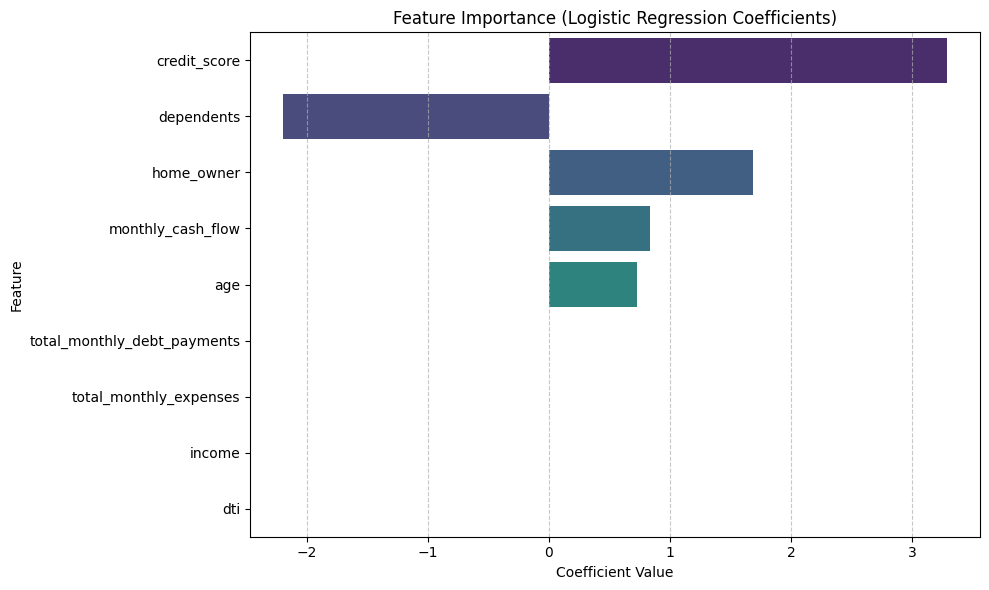

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature names from the training data
feature_names = X_train_new.columns

# Get the coefficients from the best Logistic Regression model
coefficients = best_log_reg_model.coef_[0]

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

# Sort by absolute coefficient value to see most impactful features
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Interpreting the Visualization

*   **Positive Coefficients:** Features with positive coefficients (bars extending to the right) increase the likelihood of loan approval as their values increase. For example, a higher `income` or `credit_score` would contribute positively.
*   **Negative Coefficients:** Features with negative coefficients (bars extending to the left) decrease the likelihood of loan approval as their values increase. For example, a higher `dti` (Debt-to-Income ratio) would likely contribute negatively.
*   **Magnitude:** The longer the bar (either positive or negative), the stronger the influence of that feature on the model's prediction. This helps us understand which factors are most critical in the loan approval decision.

Combined with the performance metrics (accuracy, confusion matrix, classification report) and the examples of predictions on custom data we've already generated, this visualization gives a comprehensive view of how our model operates and what drives its decisions.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
